In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

print("setup works")

setup works


In [7]:
import sys
sys.path.append("../src")
from returns import add_returns

conn = sqlite3.connect("../data/market.db")
prices = pd.read_sql_query("SELECT * FROM prices ORDER BY ticker, date", conn)
conn.close()

prices = add_returns(prices)
prices.head()

,ticker,date,open,high,low,close,adj_close,volume,simple_return,log_return
0,GLD,2014-01-02,117.930000,118.730003,117.750000,118.000000,118.000000,7551000,NaN,NaN
1,GLD,2014-01-03,118.639999,119.620003,118.589996,119.290001,119.290001,5874400,0.010932,0.010873
2,GLD,2014-01-06,119.760002,120.389999,117.110001,119.500000,119.500000,10106500,0.001760,0.001759
3,GLD,2014-01-07,118.459999,118.919998,118.129997,118.820000,118.820000,6433700,-0.005690,-0.005707
4,GLD,2014-01-08,117.989998,118.519997,117.500000,118.120003,118.120003,7428500,-0.005891,-0.005909


In [10]:
prices['ticker'].unique()

<StringArray>
['GLD', 'QQQ', 'SPY', 'TLT', 'XLE', 'XLF', 'XLK']
Length: 7, dtype: str

In [11]:
prices[prices["ticker"].isin(["GLD", "QQQ"])].iloc[3170:3180]

,ticker,date,open,high,low,close,adj_close,volume,simple_return,log_return
3170,GLD,2026-08-12,405.309998,407.359985,403.220001,404.920013,404.920013,10383100,0.009876,0.009828
3171,GLD,2026-08-13,402.170013,402.579987,398.279999,398.959991,398.959991,8695200,-0.014719,-0.014828
3172,GLD,2026-08-14,402.179993,403.329987,400.940002,401.480011,401.480011,6749800,0.006316,0.006297
3173,GLD,2026-08-17,402.339996,406.230011,402.179993,405.489990,405.489990,9604100,0.009988,0.009938
3174,GLD,2026-08-18,402.549988,404.320007,397.869995,398.549988,398.549988,10660900,-0.017115,-0.017263
3175,GLD,2026-08-19,408.809998,414.000000,407.470001,413.839996,413.839996,17480700,0.038364,0.037646
3176,GLD,2026-08-20,410.079987,416.450012,409.820007,415.260010,415.260010,13900900,0.003431,0.003425
3177,GLD,2026-08-21,420.529999,424.890015,419.420013,423.359985,423.359985,14529000,0.019506,0.019318
3178,GLD,2026-08-24,428.549988,429.420013,424.200012,426.690002,426.690002,18943000,0.007866,0.007835
3179,GLD,2026-08-25,422.779999,428.140015,422.329987,428.070007,428.070007,12450600,0.003234,0.003229


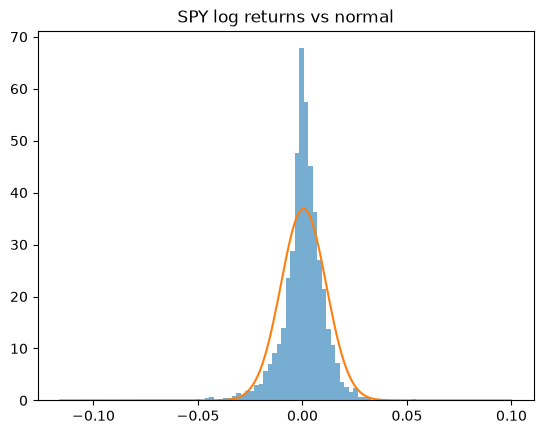

In [12]:
from scipy.stats import norm

spy_log = prices[prices["ticker"] == "SPY"]["log_return"].dropna()

plt.hist(spy_log, bins=100, density=True, alpha=0.6)

x = np.linspace(spy_log.min(), spy_log.max(), 200)
plt.plot(x, norm.pdf(x, spy_log.mean(), spy_log.std()))
plt.title("SPY log returns vs normal")
plt.show()

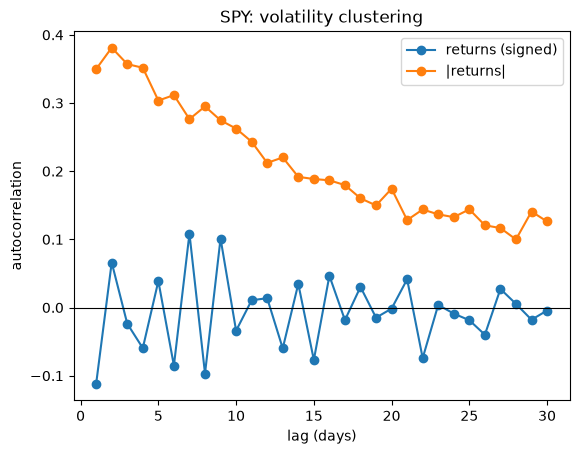

In [13]:
spy_log = prices[prices["ticker"] == "SPY"]["log_return"].dropna()

lags = range(1, 31)
acf_signed = [spy_log.autocorr(lag) for lag in lags]
acf_abs    = [spy_log.abs().autocorr(lag) for lag in lags]

plt.plot(lags, acf_signed, marker="o", label="returns (signed)")
plt.plot(lags, acf_abs, marker="o", label="|returns|")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("lag (days)")
plt.ylabel("autocorrelation")
plt.title("SPY: volatility clustering")
plt.legend()
plt.show()